# GEARS Learning

## DATA

### (1) Load Processed Data

#### pert_data.load()

In [1]:
import sys

sys.path.append('../GEARS/')

from gears import PertData

pert_data = PertData('./data') # specific saved folder

# pert_data.load()
# support norman adamson dixit replogle_k562_essential replogle_rpe1_essential
# download five dataset or read perturb_processed.h5ad directly
# 建立扰动基因表，并 clean those perturbation that is not in go graph
# 构架图数据
pert_data.load(data_name = 'norman')

/opt/anaconda3/envs/GEARS/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/GEARS/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/opt/anaconda3/envs/GEARS/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/opt/anaconda3/envs/GEARS/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_D

In [2]:
# the structure of per_data.dataset_processed in pert_data.load()
# dataset_processed = {
#   condition_1: [cell_graph, cell_graph, cell_graph, ...],
#   condition_2: [cell_graph, cell_graph, cell_graph, ...],
#   ...
# }
# 值是一个列表，列表里的每个元素是一个 cell graph 一个cell graph是torch_geometric.data.data.Data 的数据形式 存着Data(x=[5045, 1], y=[1, 5045], pert_idx=[1], de_idx=[20], pert='TSC22D1+ctrl') 这些内容 x=[5045, 1]：输入节点特征  y=[1, 5045]：目标/标签 pert_idx=[1]：扰动基因索引 de_idx=[20]：top 差异基因索引列表 	pert='TSC22D1+ctrl'：扰动条件
sub = pert_data.dataset_processed
print("the type of sub:", type(sub))

conds = list(sub.keys())[:5]

for cond in conds:
    graphs = sub[cond]
    print("\n====", cond, "====  num_cell_graphs:", len(graphs))
    for i, g in enumerate(graphs[:5]):
        print(f"[{i}] {g}","type: ",type(g))

the type of sub: <class 'dict'>

==== TSC22D1+ctrl ====  num_cell_graphs: 376
[0] Data(x=[5045, 1], y=[1, 5045], pert_idx=[1], de_idx=[20], pert='TSC22D1+ctrl') type:  <class 'torch_geometric.data.data.Data'>
[1] Data(x=[5045, 1], y=[1, 5045], pert_idx=[1], de_idx=[20], pert='TSC22D1+ctrl') type:  <class 'torch_geometric.data.data.Data'>
[2] Data(x=[5045, 1], y=[1, 5045], pert_idx=[1], de_idx=[20], pert='TSC22D1+ctrl') type:  <class 'torch_geometric.data.data.Data'>
[3] Data(x=[5045, 1], y=[1, 5045], pert_idx=[1], de_idx=[20], pert='TSC22D1+ctrl') type:  <class 'torch_geometric.data.data.Data'>
[4] Data(x=[5045, 1], y=[1, 5045], pert_idx=[1], de_idx=[20], pert='TSC22D1+ctrl') type:  <class 'torch_geometric.data.data.Data'>

==== KLF1+MAP2K6 ====  num_cell_graphs: 222
[0] Data(x=[5045, 1], y=[1, 5045], pert_idx=[2], de_idx=[20], pert='KLF1+MAP2K6') type:  <class 'torch_geometric.data.data.Data'>
[1] Data(x=[5045, 1], y=[1, 5045], pert_idx=[2], de_idx=[20], pert='KLF1+MAP2K6') type:  <cl

In [3]:
# the instant structure of cell_graphs.pkl
import pickle
cell_graphs = "data/norman/data_pyg/cell_graphs.pkl"
with open(cell_graphs, "rb") as f:
    cell_graphs = pickle.load(f)
print("type:",type(cell_graphs),"  lens:", len(cell_graphs))
items = list(cell_graphs.items())[:5]
for i, (k, v) in enumerate(items, 1):
    print(f"\n[{i}] key={k}  type(value)={type(v)}  len(value)={len(v)}")
    print("    type(value[0]) =", type(v[0]))
    print("    value[0] =", v[0])


type: <class 'dict'>   lens: 277

[1] key=TSC22D1+ctrl  type(value)=<class 'list'>  len(value)=376
    type(value[0]) = <class 'torch_geometric.data.data.Data'>
    value[0] = Data(x=[5045, 1], y=[1, 5045], pert_idx=[1], de_idx=[20], pert='TSC22D1+ctrl')

[2] key=KLF1+MAP2K6  type(value)=<class 'list'>  len(value)=222
    type(value[0]) = <class 'torch_geometric.data.data.Data'>
    value[0] = Data(x=[5045, 1], y=[1, 5045], pert_idx=[2], de_idx=[20], pert='KLF1+MAP2K6')

[3] key=ctrl  type(value)=<class 'list'>  len(value)=7353
    type(value[0]) = <class 'torch_geometric.data.data.Data'>
    value[0] = Data(x=[5045, 1], y=[1, 5045], pert_idx=[1], de_idx=[20], pert='ctrl')

[4] key=CEBPE+RUNX1T1  type(value)=<class 'list'>  len(value)=1030
    type(value[0]) = <class 'torch_geometric.data.data.Data'>
    value[0] = Data(x=[5045, 1], y=[1, 5045], pert_idx=[2], de_idx=[20], pert='CEBPE+RUNX1T1')

[5] key=MAML2+ctrl  type(value)=<class 'list'>  len(value)=508
    type(value[0]) = <class '

#### pert_data.prepare_split()

In [4]:
# pert_data.prepare_split()
pert_data.prepare_split(split = 'simulation', seed = 1) # get data split with seed

Creating new splits....
Saving new splits at ./data/norman/splits/norman_simulation_1_0.75.pkl
Simulation split test composition:
combo_seen0:9
combo_seen1:43
combo_seen2:19
unseen_single:36
Done!


In [5]:
print(type(pert_data.subgroup))
print(list(pert_data.subgroup.keys()))

<class 'dict'>
['test_subgroup', 'val_subgroup']


In [6]:
sub = pert_data.subgroup["test_subgroup"]

keys = list(sub.keys())[:5]   # 前5个子类名
for i, key in enumerate(keys, 1):
    print(f"\n[{i}] subgroup={key}  type={type(key)}  num_conditions={len(sub[key])}")
    print("first few conditions:", sub[key][:10])


[1] subgroup=combo_seen0  type=<class 'str'>  num_conditions=9
first few conditions: ['CBL+PTPN9', 'DUSP9+PRTG', 'FOXL2+MEIS1', 'CEBPB+OSR2', 'JUN+CEBPB', 'CDKN1C+CDKN1B', 'CDKN1C+CDKN1A', 'CDKN1B+CDKN1A', 'C3orf72+FOXL2']

[2] subgroup=combo_seen1  type=<class 'str'>  num_conditions=43
first few conditions: ['MAP2K6+SPI1', 'DUSP9+MAPK1', 'UBASH3B+OSR2', 'DUSP9+ETS2', 'ZNF318+FOXL2', 'UBASH3B+PTPN9', 'JUN+CEBPA', 'MAPK1+PRTG', 'KLF1+COL2A1', 'PTPN12+OSR2']

[3] subgroup=combo_seen2  type=<class 'str'>  num_conditions=19
first few conditions: ['AHR+KLF1', 'CEBPE+CNN1', 'CEBPE+KLF1', 'CNN1+MAPK1', 'ETS2+CEBPE', 'ETS2+CNN1', 'ETS2+MAPK1', 'FEV+ISL2', 'FOSB+CEBPE', 'FOXA1+HOXB9']

[4] subgroup=unseen_single  type=<class 'str'>  num_conditions=36
first few conditions: ['DUSP9+ctrl', 'BCORL1+ctrl', 'MEIS1+ctrl', 'CBL+ctrl', 'SLC4A1+ctrl', 'COL2A1+ctrl', 'S1PR2+ctrl', 'CELF2+ctrl', 'CDKN1A+ctrl', 'ctrl+MEIS1']


In [7]:
sub = pert_data.subgroup["val_subgroup"]

keys = list(sub.keys())[:5]   # 前5个子类名
for i, key in enumerate(keys, 1):
    print(f"\n[{i}] subgroup={key}  type={type(key)}  num_conditions={len(sub[key])}")
    print("first few conditions:", sub[key][:10])


[1] subgroup=combo_seen0  type=<class 'str'>  num_conditions=0
first few conditions: []

[2] subgroup=combo_seen1  type=<class 'str'>  num_conditions=13
first few conditions: ['LHX1+ELMSAN1', 'KLF1+BAK1', 'KLF1+TGFBR2', 'KLF1+CEBPA', 'SGK1+TBX2', 'SET+KLF1', 'SAMD1+ZBTB1', 'KLF1+CLDN6', 'KLF1+MAP2K6', 'BPGM+ZBTB1']

[3] subgroup=combo_seen2  type=<class 'str'>  num_conditions=5
first few conditions: ['ETS2+MAP7D1', 'FEV+CBFA2T3', 'FOSB+IKZF3', 'FOSB+PTPN12', 'TGFBR2+ETS2']

[4] subgroup=unseen_single  type=<class 'str'>  num_conditions=13
first few conditions: ['ctrl+ELMSAN1', 'KLF1+ctrl', 'ctrl+KLF1', 'ctrl+TBX2', 'C19orf26+ctrl', 'ZBTB1+ctrl', 'ARRDC3+ctrl', 'ctrl+ZBTB1', 'ctrl+C19orf26', 'CNNM4+ctrl']


In [8]:
# the instant structure of norman_simulation_1_0.75.pkl
import pickle
cell_graphs = "data/norman/splits/norman_simulation_1_0.75.pkl"
with open(cell_graphs, "rb") as f:
    cell_graphs = pickle.load(f)
print("type:",type(cell_graphs),"  lens:", len(cell_graphs))
items = list(cell_graphs.items())[:5]
for i, (k, v) in enumerate(items, 1):
    print(f"\n[{i}] key={k}  type(value)={type(v)}  len(value)={len(v)}")
    print("    type(value) =", type(v))
    print("    value =", v)

type: <class 'dict'>   lens: 3

[1] key=test  type(value)=<class 'list'>  len(value)=107
    type(value) = <class 'list'>
    value = ['CBL+PTPN9', 'DUSP9+ctrl', 'MAP2K6+SPI1', 'UBASH3B+PTPN12', 'BCORL1+ctrl', 'MEIS1+ctrl', 'CBL+ctrl', 'KLF1+FOXA1', 'TBX3+TBX2', 'SLC4A1+ctrl', 'DUSP9+MAPK1', 'COL2A1+ctrl', 'CEBPE+KLF1', 'UBASH3B+OSR2', 'UBASH3B+ZBTB25', 'DUSP9+ETS2', 'ZNF318+FOXL2', 'UBASH3B+PTPN9', 'S1PR2+ctrl', 'CELF2+ctrl', 'JUN+CEBPA', 'CDKN1A+ctrl', 'ctrl+MEIS1', 'MAPK1+PRTG', 'MAP2K3+IKZF3', 'KLF1+COL2A1', 'PTPN12+OSR2', 'ETS2+CEBPE', 'POU3F2+FOXL2', 'DUSP9+PRTG', 'CKS1B+ctrl', 'BCL2L11+TGFBR2', 'AHR+KLF1', 'CEBPB+CEBPA', 'PRTG+ctrl', 'ETS2+CNN1', 'C3orf72+ctrl', 'CNN1+MAPK1', 'FOXL2+MEIS1', 'FOXL2+ctrl', 'FOSB+CEBPE', 'PTPN12+PTPN9', 'FOSB+CEBPB', 'ctrl+CDKN1A', 'BCL2L11+BAK1', 'FOXA3+HOXB9', 'ARID1A+ctrl', 'ctrl+COL2A1', 'CEBPE+CNN1', 'ZC3HAV1+HOXC13', 'CBL+CNN1', 'ZBTB10+PTPN12', 'CBL+UBASH3B', 'CEBPB+PTPN12', 'BCL2L11+ctrl', 'OSR2+ctrl', 'ctrl+SPI1', 'CEBPB+MAPK1', 'ETS2+MAPK

In [9]:
# the instant structure of norman_simulation_1_0.75_subgroup.pkl
import pickle
cell_graphs = "data/norman/splits/norman_simulation_1_0.75_subgroup.pkl"
with open(cell_graphs, "rb") as f:
    cell_graphs = pickle.load(f)
print("type:",type(cell_graphs),"  lens:", len(cell_graphs))
items = list(cell_graphs.items())[:5]
for i, (k, v) in enumerate(items, 1):
    print(f"\n[{i}] key={k}  type(value)={type(v)}  len(value)={len(v)}")
    print("    type(value) =", type(v))
    print("    value =", v)

type: <class 'dict'>   lens: 2

[1] key=test_subgroup  type(value)=<class 'dict'>  len(value)=4
    type(value) = <class 'dict'>
    value = {'combo_seen0': ['CBL+PTPN9', 'DUSP9+PRTG', 'FOXL2+MEIS1', 'CEBPB+OSR2', 'JUN+CEBPB', 'CDKN1C+CDKN1B', 'CDKN1C+CDKN1A', 'CDKN1B+CDKN1A', 'C3orf72+FOXL2'], 'combo_seen1': ['MAP2K6+SPI1', 'DUSP9+MAPK1', 'UBASH3B+OSR2', 'DUSP9+ETS2', 'ZNF318+FOXL2', 'UBASH3B+PTPN9', 'JUN+CEBPA', 'MAPK1+PRTG', 'KLF1+COL2A1', 'PTPN12+OSR2', 'POU3F2+FOXL2', 'BCL2L11+TGFBR2', 'CEBPB+CEBPA', 'PTPN12+PTPN9', 'FOSB+CEBPB', 'BCL2L11+BAK1', 'CBL+CNN1', 'ZBTB10+PTPN12', 'CBL+UBASH3B', 'CEBPB+PTPN12', 'CEBPB+MAPK1', 'DUSP9+IGDCC3', 'CBL+PTPN12', 'SGK1+S1PR2', 'DUSP9+KLF1', 'CEBPE+SPI1', 'CBL+TGFBR2', 'FOXA1+FOXL2', 'FOXF1+FOXL2', 'ETS2+PRTG', 'LYL1+CEBPB', 'DUSP9+SNAI1', 'TGFBR2+PRTG', 'FOSB+OSR2', 'FOXL2+HOXB9', 'ZBTB10+ELMSAN1', 'ZBTB10+SNAI1', 'CEBPE+CEBPB', 'PRDM1+CBFA2T3', 'FOXA3+FOXL2', 'ZBTB10+DLX2', 'CBL+UBASH3A', 'IGDCC3+PRTG'], 'combo_seen2': ['AHR+KLF1', 'CEBPE+CNN1'

#### pert_data.get_dataloader()

In [10]:
pert_data.get_dataloader(batch_size=32, test_batch_size=128)

Creating dataloaders....
Done!


In [11]:
print(type(pert_data.dataloader))
print(pert_data.dataloader.keys())
train_loader = pert_data.dataloader["train_loader"]
val_loader   = pert_data.dataloader["val_loader"]
test_loader  = pert_data.dataloader["test_loader"]

print("num graphs:", len(train_loader.dataset))
batch = next(iter(train_loader))
print(batch)
print(batch.keys())

<class 'dict'>
dict_keys(['train_loader', 'val_loader', 'test_loader'])
num graphs: 49849
DataBatch(x=[161440, 1], y=[32, 5045], pert_idx=[32], de_idx=[32], pert=[32], batch=[161440], ptr=[33])
['ptr', 'y', 'de_idx', 'pert', 'x', 'pert_idx', 'batch']


### (2) Create your own Perturb-Seq data
Prepare a scanpy adata object with 
1. `adata.obs` dataframe has `condition` and `cell_type` columns, where `condition` is the perturbation name for each cell. Control cells have condition format of `ctrl`, single perturbation has condition format of `A+ctrl` or `ctrl+A`, combination perturbation has condition format of `A+B`.
2. `adata.var` dataframe has `gene_name` column, where each gene name is the gene symbol.
3. `adata.X` stores the post-perturbed gene expression. 

Here an example using dixit 2016 dataset.

##### the instant structure of perturb_processed.h5ad and AnnData

In [12]:
### Data meaning:
##### AnnData object: is specifically designed for matrix-like data.
##### By this we mean that we have n observations, each of which can be represented as d-dimensional vectors
##### where each dimension corresponds to a variable or feature.
##### Both the rows and columns of this n * d matrix are special in the sense that they are indexed.
##### n_obs: 观察对象 n_vars: 基因数 一整个AnnData object 是n_obs * n_vars 的matrix-like data
##### obs: 1. condition: 细胞属于哪个扰动条件
#####      2. cell_type: 细胞类型
#####      3. dose_val: 剂量信息( 1+1 表示两种扰动各 1 的剂量；1 表示单个)
#####      4. control: 是否对照(ctrl ==1 else 0)
#####      5. condition_name: 完整名字 f"{cell_type}_{condition}_{dose_val}"
##### var: 1. gene_name: 基因表
##### uns: 1. non_dropout_gene_idx: 一组基因索引（index），挑出“不容易掉零（dropout 少）”的基因,选一批更“稳定、可用”的基因做训练/评估/差异(dropout
#####      在单细胞里指：某个基因实际有表达，但由于测序/捕获随机性，出现大量 0)
#####      2. non_zeros_gene_idx: 一组基因索引，挑出“总体上非零表达较多”的基因
#####      3. rank_genes_groups_cov_all: 按分组做差异基因排名的结果对象
#####      4. top_non_dropout_de_20: 每个组/每个扰动条件下，top 20 差异基因
#####      5. top_non_zero_de_20: 每组/每扰动条件下的 top 20 差异基因(基因集合来自“non_zeros”)
##### layers: counts: 存不同版本的表达矩阵

In [13]:
import scanpy as sc

h5ads = "data/norman/perturb_processed.h5ad"
adata0 = sc.read_h5ad(h5ads)
print(adata0)
print(adata0.obs.head())
print(adata0.var.head())

AnnData object with n_obs × n_vars = 91205 × 5045
    obs: 'condition', 'cell_type', 'dose_val', 'control', 'condition_name'
    var: 'gene_name'
    uns: 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'
    layers: 'counts'
                        condition cell_type dose_val  control  \
cell_barcode                                                    
AAACCTGAGGCATGTG-1   TSC22D1+ctrl      A549      1+1        0   
AAACCTGAGGCCCTTG-1    KLF1+MAP2K6      A549      1+1        0   
AAACCTGCACGAAGCA-1           ctrl      A549        1        1   
AAACCTGCAGACGTAG-1  CEBPE+RUNX1T1      A549      1+1        0   
AAACCTGCAGCCTTGG-1     MAML2+ctrl      A549      1+1        0   

                            condition_name  
cell_barcode                                
AAACCTGAGGCATGTG-1   A549_TSC22D1+ctrl_1+1  
AAACCTGAGGCCCTTG-1    A549_KLF1+MAP2K6_1+1  
AAACCTGCACGAAGCA-1             A549_ctrl_1  
AAACCTGCAGACGTAG-1  A5

In [14]:
cell = "AAACCTGAGGCATGTG-1"

# 取原始计数（更直观）
row = adata0.layers["counts"][adata0.obs_names == cell, :]

# 稀疏矩阵转成普通数组方便看
row = row.toarray().ravel() if hasattr(row, "toarray") else row.ravel()

print("向量长度(基因数):", row.shape[0])
print("前 20 个基因的表达值:", row[:20])
i = 5  # 第六个（0-based 索引）
print("gene_id:", adata0.var_names[i])
print("gene_name:", adata0.var["gene_name"].iloc[i])
print("this cell count:", row[i])

向量长度(基因数): 5045
前 20 个基因的表达值: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
gene_id: ENSG00000187608
gene_name: ISG15
this cell count: 1.0


In [15]:
import pprint
print(type(pert_data))
pprint.pprint([k for k in dir(pert_data) if not k.startswith("_")])

<class 'gears.pertdata.PertData'>
['adata',
 'create_cell_graph',
 'create_cell_graph_dataset',
 'create_dataset_file',
 'ctrl_adata',
 'data_path',
 'dataloader',
 'dataset_name',
 'dataset_path',
 'dataset_processed',
 'default_pert_graph',
 'gene2go',
 'gene_names',
 'gene_set_path',
 'get_dataloader',
 'get_pert_idx',
 'load',
 'new_data_process',
 'node_map',
 'node_map_pert',
 'pert_names',
 'prepare_split',
 'seed',
 'set2conditions',
 'set_pert_genes',
 'split',
 'subgroup',
 'train_gene_set_size']


#### Suggested normalization

For raw count data we recommend the following normalization and subsetting to the top 5000 most variable genes

In [16]:
sc.pp.normalize_total(adata0) # Normalize counts per cell
sc.pp.log1p(adata0) # Logarithmize the data matrix x = log(x+1)
sc.pp.highly_variable_genes(adata0,n_top_genes=5000, subset=True)

In [17]:
 # Compare before vs after Scanpy preprocessing (normalize_total, log1p, HVG)
import numpy as np
import pandas as pd
import scanpy as sc

# ===== 0) Backup raw (before processing) =====
adata_raw = adata0.copy()

# Choose one cell and a small gene panel to inspect
cell = adata_raw.obs_names[0]
genes = adata_raw.var["gene_name"].values[:10].tolist()  # first 10 gene symbols (you can change)

# Helper to safely fetch a 1xN row vector from X or a layer
def fetch_row(adata, cell_id, gene_list, use_layer=None):
    gene_set = set(adata.var["gene_name"].values)
    genes_present = [g for g in gene_list if g in gene_set]
    if len(genes_present) == 0:
        return genes_present, np.array([])

    mask = adata.var["gene_name"].isin(genes_present)
    row = adata.layers[use_layer][adata.obs_names == cell_id, mask] if use_layer else adata.X[adata.obs_names == cell_id, mask]
    row = row.toarray().ravel() if hasattr(row, "toarray") else np.asarray(row).ravel()
    return genes_present, row

# ===== 1) Before: counts (preferred) or X =====
use_counts = "counts" in adata_raw.layers
genes_b, row_counts = fetch_row(adata_raw, cell, genes, use_layer="counts" if use_counts else None)

print("=== BEFORE ===")
print("cell:", cell)
print("matrix used:", "layers['counts']" if use_counts else "X")
print("n_obs x n_vars:", adata_raw.n_obs, "x", adata_raw.n_vars)

before_df = pd.DataFrame({"gene_name": genes_b, "value": row_counts})
display(before_df)

# ===== 2) Run preprocessing (in-place on adata0) =====
sc.pp.normalize_total(adata0)
sc.pp.log1p(adata0)
sc.pp.highly_variable_genes(adata0, n_top_genes=5000, subset=True)

# ===== 3) After: X (log-normalized) =====
genes_a, row_after = fetch_row(adata0, cell, genes)  # after HVG, some genes may be missing

print("\n=== AFTER ===")
print("cell:", cell)
print("matrix used:", "X (log-normalized)")
print("n_obs x n_vars:", adata0.n_obs, "x", adata0.n_vars)

after_df = pd.DataFrame({"gene_name": genes_a, "value": row_after})
display(after_df)

# ===== 4) Quick global summary (small blocks) =====
def summarize_block(mat, name):
    m = mat
    m = m.toarray() if hasattr(m, "toarray") else np.asarray(m)
    print(f"\n== {name} ==")
    print("shape:", m.shape)
    print("min/mean/max:", float(m.min()), float(m.mean()), float(m.max()))
    print("nonzero fraction:", float((m > 0).mean()))

summarize_block(adata_raw.layers["counts"][:200, :200] if use_counts else adata_raw.X[:200, :200], "BEFORE (200x200)")
summarize_block(adata0.X[:200, :200], "AFTER (200x200)")

print("\nGenes before:", adata_raw.n_vars, " | Genes after HVG subset:", adata0.n_vars)

=== BEFORE ===
cell: AAACCTGAGGCATGTG-1
matrix used: layers['counts']
n_obs x n_vars: 91205 x 5000


,gene_name,value
0,RP11-34P13.8,0.0
1,RP11-54O7.3,0.0
2,SAMD11,0.0
3,PERM1,0.0
4,HES4,0.0
5,ISG15,1.0
6,RP11-54O7.18,0.0
7,RNF223,0.0
8,LINC01342,0.0
9,TTLL10-AS1,0.0



=== AFTER ===
cell: AAACCTGAGGCATGTG-1
matrix used: X (log-normalized)
n_obs x n_vars: 91205 x 5000


,gene_name,value
0,RP11-34P13.8,0.000000
1,RP11-54O7.3,0.000000
2,SAMD11,0.000000
3,PERM1,0.000000
4,HES4,0.000000
5,ISG15,0.414988
6,RP11-54O7.18,0.000000
7,RNF223,0.000000
8,LINC01342,0.000000
9,TTLL10-AS1,0.000000



== BEFORE (200x200) ==
shape: (200, 200)
min/mean/max: 0.0 0.733299970626831 136.0
nonzero fraction: 0.120225

== AFTER (200x200) ==
shape: (200, 200)
min/mean/max: 0.0 0.0713997557759285 1.2853986024856567
nonzero fraction: 0.120225

Genes before: 5000  | Genes after HVG subset: 5000


## MODEL

In [20]:
from gears import *

gears_model = GEARS(pert_data,device="cpu",
                    weight_bias_track=False,
                    proj_name="pertnet",
                    exp_name="pertnet")
gears_model.model_initialize(hidden_size=64)

Found local copy...


In [21]:
gears_model.tunable_parameters()

{'hidden_size': 'hidden dimension, default 64',
 'num_go_gnn_layers': 'number of GNN layers for GO graph, default 1',
 'num_gene_gnn_layers': 'number of GNN layers for co-expression gene graph, default 1',
 'decoder_hidden_size': 'hidden dimension for gene-specific decoder, default 16',
 'num_similar_genes_go_graph': 'number of maximum similar K genes in the GO graph, default 20',
 'num_similar_genes_co_express_graph': 'number of maximum similar K genes in the co expression graph, default 20',
 'coexpress_threshold': 'pearson correlation threshold when constructing coexpression graph, default 0.4',
 'uncertainty': 'whether or not to turn on uncertainty mode, default False',
 'uncertainty_reg': 'regularization term to balance uncertainty loss and prediction loss, default 1',
 'direction_lambda': 'regularization term to balance direction loss and prediction loss, default 1'}

In [22]:
gears_model.train(epochs=1,lr=0.001)

Start Training...
Epoch 1 Step 1 Train Loss: 0.4881
Epoch 1 Step 51 Train Loss: 0.4644
Epoch 1 Step 101 Train Loss: 0.4212
Epoch 1 Step 151 Train Loss: 0.4673
Epoch 1 Step 201 Train Loss: 0.4260
Epoch 1 Step 251 Train Loss: 0.4139
Epoch 1 Step 301 Train Loss: 0.4827
Epoch 1 Step 351 Train Loss: 0.4890
Epoch 1 Step 401 Train Loss: 0.4922
Epoch 1 Step 451 Train Loss: 0.5242
Epoch 1 Step 501 Train Loss: 0.4430
Epoch 1 Step 551 Train Loss: 0.4824
Epoch 1 Step 601 Train Loss: 0.4954
Epoch 1 Step 651 Train Loss: 0.4189
Epoch 1 Step 701 Train Loss: 0.4685
Epoch 1 Step 751 Train Loss: 0.4575
Epoch 1 Step 801 Train Loss: 0.4620
Epoch 1 Step 851 Train Loss: 0.4217
Epoch 1 Step 901 Train Loss: 0.4485
Epoch 1 Step 951 Train Loss: 0.4931
Epoch 1 Step 1001 Train Loss: 0.4661
Epoch 1 Step 1051 Train Loss: 0.5499
Epoch 1 Step 1101 Train Loss: 0.3782
Epoch 1 Step 1151 Train Loss: 0.4453
Epoch 1 Step 1201 Train Loss: 0.4943
Epoch 1 Step 1251 Train Loss: 0.3957
Epoch 1 Step 1301 Train Loss: 0.4431
Epoch 

In [23]:
gears_model.save_model("test_model")
gears_model.load_pretrained("test_model")

In [24]:
gears_model.predict([['FEV'], ['FEV', 'AHR']])

{'FEV': array([-2.8368812e-09, -6.1237849e-02,  1.0085314e-01, ...,
         3.0566812e+00, -1.2979068e-02,  3.5924891e-25], dtype=float32),
 'FEV_AHR': array([-3.7352916e-09, -5.2985992e-02,  1.6322780e-01, ...,
         2.8232181e+00, -1.3288792e-02,  4.7072528e-25], dtype=float32)}

In [25]:
gears_model.gene_list[:5]

['RP11-34P13.8', 'RP11-54O7.3', 'SAMD11', 'PERM1', 'HES4']

In [29]:
gears_model.GI_predict(['FEV','AHR'],GI_genes_file=N)

{'ts': TheilSenRegressor(fit_intercept=False, max_iter=1000,
                   max_subpopulation=100000.0, random_state=1000),
 'c1': 0.39258235800726304,
 'c2': 0.8454315387535758,
 'mag': 0.9321348585573773,
 'dcor': 0.9751419429752585,
 'dcor_singles': 0.9870424590655555,
 'dcor_first': 0.9693451799399748,
 'dcor_second': 0.9775534707997223,
 'corr_fit': 0.9828274188344287,
 'dominance': 0.33314766587803546,
 'eq_contr': 0.9916032308155661}

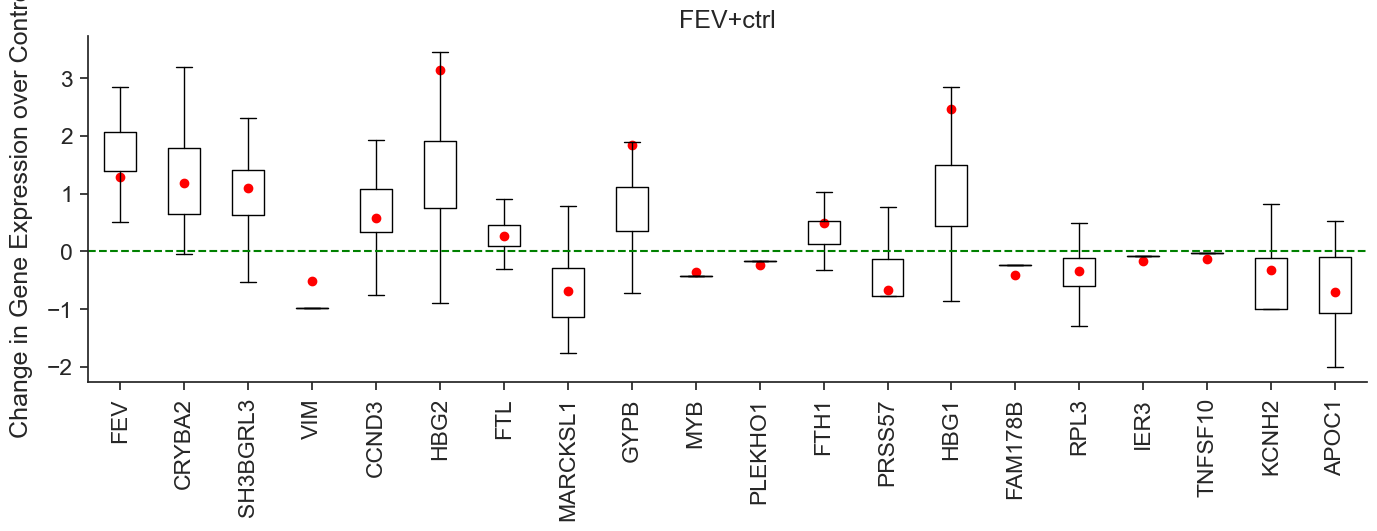

In [35]:
gears_model.plot_perturbation('FEV+ctrl')